A comparison of the three models tested in model_testing.py


In [12]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
results_path = "../outputs/results/"
preds_path = "../outputs/preds/"
fairness_file = os.path.join(results_path, "fairness_metrics.json")

# Load fairness metrics
with open(fairness_file, 'r') as f:
    fairness = json.load(f)
    print(fairness)

# Load classification reports
report_files = [f for f in os.listdir(results_path) if f.endswith('.json') and f != "fairness_metrics.json"]
reports = {}
for file in report_files:
    model_name = file.replace(".json", "")
    with open(os.path.join(results_path, file), 'r') as f:
        reports[model_name] = json.load(f)[model_name]
print(reports)


{'Logistic Regression': {'accuracy': {'0': 0.753686327077748, '1': 0.7186932849364791}, 'selection_rate': {'0': 0.2761394101876676, '1': 0.4467909585876918}}, 'Random Forest': {'accuracy': {'0': 0.8200402144772118, '1': 0.7317274377165485}, 'selection_rate': {'0': 0.1601876675603217, '1': 0.26249793763405377}}, 'Gradient Boosting': {'accuracy': {'0': 0.7945710455764075, '1': 0.7447615904966177}, 'selection_rate': {'0': 0.22788203753351208, '1': 0.3801352912060716}}}
{'Gradient Boosting': {'0': {'precision': 0.8812091503267974, 'recall': 0.7927384977215934, 'f1-score': 0.8346359204519075, 'support': 6803.0}, '1': {'precision': 0.517948717948718, 'recall': 0.6757359500446031, 'f1-score': 0.5864137797561447, 'support': 2242.0}, 'accuracy': 0.7637368711995578, 'macro avg': {'precision': 0.6995789341377576, 'recall': 0.7342372238830983, 'f1-score': 0.7105248501040261, 'support': 9045.0}, 'weighted avg': {'precision': 0.791167150394055, 'recall': 0.7637368711995578, 'f1-score': 0.77310866346

In [14]:
data = np.load("../outputs/preds/Gradient Boosting_preds.npz")
y_test, y_pred, s_test = data["y_test"], data["y_pred"], data["s_test"]

# Group-wise selection rate (who was predicted >50K)
df = pd.DataFrame({"y_true": y_test, "y_pred": y_pred, "group": s_test})
print(pd.crosstab(df["group"], df["y_pred"], normalize='index'))


y_pred         0         1
group                     
0       0.780831  0.219169
1       0.625309  0.374691


In [15]:
print(pd.crosstab(df["group"], df["y_true"], normalize='index'))


y_true         0         1
group                     
0       0.881702  0.118298
1       0.688335  0.311665


Label gap(19%) is larger than prediction gap(15.5%)=
The model predicts more high-income cases than actually exist in both groups: suggests a mildly optimistic bias.
SMOTE may help close fairness gap 


In [17]:
# Load predictions
model = ['Gradient Boosting_preds.npz','Logistic Regression_preds.npz', 'Random Forest_preds.npz']
for m in model: 
    path_npz = os.path.join('../outputs/preds/', m)
    logreg_data = np.load(path_npz)
    y_test_lr = logreg_data["y_test"]
    y_pred_lr = logreg_data["y_pred"]
    s_test_lr = logreg_data["s_test"]

    # Crosstabs
    df_lr = pd.DataFrame({"y_true": y_test_lr, "y_pred": y_pred_lr, "group": s_test_lr})
    print(f"{m} — Predicted Selection Rate:")
    print(pd.crosstab(df_lr["group"], df_lr["y_pred"], normalize='index'))

    print(f"\n{m} — Actual Income Distribution:")
    print(pd.crosstab(df_lr["group"], df_lr["y_true"], normalize='index'))

Gradient Boosting_preds.npz — Predicted Selection Rate:
y_pred         0         1
group                     
0       0.780831  0.219169
1       0.625309  0.374691

Gradient Boosting_preds.npz — Actual Income Distribution:
y_true         0         1
group                     
0       0.881702  0.118298
1       0.688335  0.311665
Logistic Regression_preds.npz — Predicted Selection Rate:
y_pred         0         1
group                     
0       0.723861  0.276139
1       0.553209  0.446791

Logistic Regression_preds.npz — Actual Income Distribution:
y_true         0         1
group                     
0       0.881702  0.118298
1       0.688335  0.311665
Random Forest_preds.npz — Predicted Selection Rate:
y_pred         0         1
group                     
0       0.839812  0.160188
1       0.737502  0.262498

Random Forest_preds.npz — Actual Income Distribution:
y_true         0         1
group                     
0       0.881702  0.118298
1       0.688335  0.311665


Logistic Regression favors Group 1 most.
Gradient Boosting shows a moderate gap.
Random Forest favors Group 0 the most.

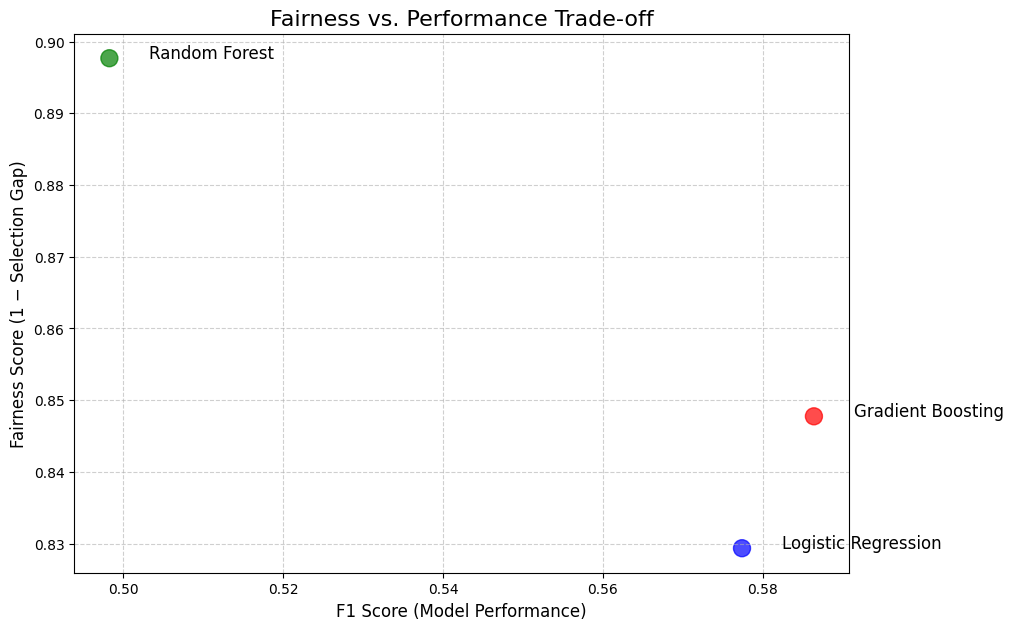

In [33]:
model_f1={}
for model_name in reports:
    #Finding the F1 rate for each model
    f1_score_1 = reports[model_name]['1']['f1-score']
    model_f1[model_name] = [f1_score_1]


selection_rate_gaps ={}
for model_name in fairness:
    #Finding the selection rate for both groups and calculating the gap 
    selection_0 = fairness[model_name]['selection_rate']['0']
    selection_1 = fairness[model_name]['selection_rate']['1']
    # Subtract difference by 1 so higher scores mean better performance ie smaller gap
    gap = 1-abs(selection_0 - selection_1)
    selection_rate_gaps[model_name]=[gap]

#Plotting a Scatterplot
model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']

x_values = [model_f1[name][0] for name in model_names]
y_values = [selection_rate_gaps[name][0] for name in model_names]

plt.figure(figsize=(10, 7))
plt.scatter(x_values, y_values, s=150, alpha=0.7, c=['blue', 'green', 'red'])

for i, model in enumerate(model_names):
    plt.text(x_values[i] + 0.005, y_values[i], model, fontsize=12)

plt.title('Fairness vs. Performance Trade-off', fontsize=16)
plt.xlabel('F1 Score (Model Performance)', fontsize=12)
plt.ylabel('Fairness Score (1 − Selection Gap)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)


This plot shows how each model balances performance (F1 score) with fairness (selection rate gap). The Gradient Boosting model stands out as it has the highest F1 score and the smallest gender gap, making it the fairest and strongest performer overall.

This matters because models like these are often used in CV filtering. Choosing a model that accounts for structural bias helps reduce unfair outcomes and can improve fairness in future data.

Of all models tested, Gradient Boosting not only reflects biased data but also helps correct for it.

Scaled Recall Gap: {'Gradient Boosting': [0.8829974523230096], 'Logistic Regression': [0.9823236796800698], 'Random Forest': [0.6252955778679266]}


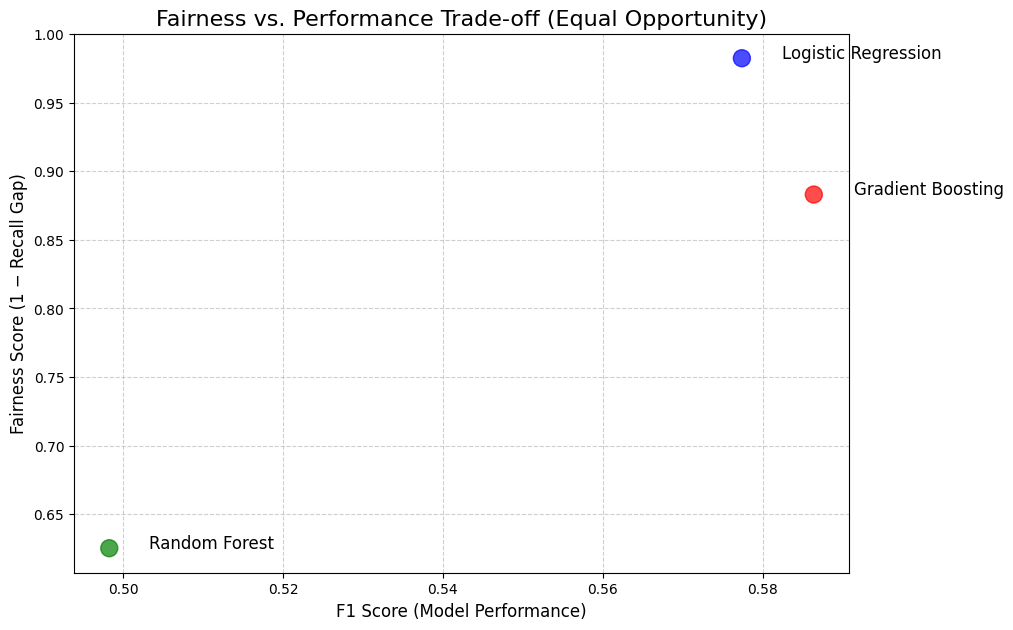

In [36]:
scaled_recall_gap={}
for model_name in reports:
    #Finding the recall rate for each model
    recall_0 = reports[model_name]['0']['recall']
    recall_1= reports[model_name]['1']['recall']
    scaled_gap = 1-abs(recall_0 - recall_1)
    scaled_recall_gap[model_name] = [scaled_gap]

print(f'Scaled Recall Gap: {scaled_recall_gap}')

x = [model_f1[name][0] for name in model_names]
y = [scaled_recall_gap[name][0] for name in model_names]

plt.figure(figsize=(10, 7))
plt.scatter(x, y, s=150, alpha=0.7, c=['blue', 'green', 'red'])

for i, model in enumerate(model_names):
    plt.text(x[i] + 0.005, y[i], model, fontsize=12)

plt.title('Fairness vs. Performance Trade-off (Equal Opportunity)', fontsize=16)
plt.xlabel('F1 Score (Model Performance)', fontsize=12)
plt.ylabel('Fairness Score (1 − Recall Gap)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)






This plot compares model performance (F1 score) against fairness measured via equal opportunity: how equally each model recalls positive outcomes across genders.

Logistic Regression scores highest on fairness (almost equal recall for both genders), though its F1 score is slightly lower.

Gradient Boosting balances both: strong performance and high fairness, with only a small recall gap.

Random Forest, accurate for one group, shows a significant drop in recall for the other, making it less fair overall.

I believe Gradient Boosting is the most appropriate choice here — it performs well and adjusts for gender-based disparities in recall. Since models like these are often used in CV filtering or other decision systems, choosing one that doesn't reinforce past social biases is crucial.

In [4]:
import numpy as np
from sklearn.metrics import classification_report
import os

model = ['Gradient Boosting_preds.npz','Logistic Regression_preds.npz', 'Random Forest_preds.npz']
for m in model: 
    path_npz = os.path.join('../outputs/preds/', m)
    logreg_data = np.load(path_npz)
    y_test_lr = logreg_data["y_test"]
    y_pred_lr = logreg_data["y_pred"]
    s_test_lr = logreg_data["s_test"]

    # Mask for high-income women
    high_income_women_mask = (s_test_lr == 0) & (y_test_lr== 1)


    # True labels and predicted labels
    y_true_hi_women = y_test_lr[high_income_women_mask]
    y_pred_hi_women_unw = y_pred_lr[high_income_women_mask]

    # Print performance
    print(f"fUnweighted model performance on high-income women {m}:")
    print(classification_report(y_true_hi_women, y_pred_hi_women_unw, zero_division=0))


fUnweighted model performance on high-income women Gradient Boosting_preds.npz:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.58      0.73       353

    accuracy                           0.58       353
   macro avg       0.50      0.29      0.37       353
weighted avg       1.00      0.58      0.73       353

fUnweighted model performance on high-income women Logistic Regression_preds.npz:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.63      0.77       353

    accuracy                           0.63       353
   macro avg       0.50      0.31      0.39       353
weighted avg       1.00      0.63      0.77       353

fUnweighted model performance on high-income women Random Forest_preds.npz:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0

Precision = 1.00: All models perfectly predict some high-income women, but...

Recall < 0.65: They miss a lot of actual high-income women.

Support = 353: This group isn’t tiny — it's large enough that poor recall directly hurts fairness.